In [1]:
import json
import os
import pickle as pkl
import openjij as oj
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from dimod import BinaryQuadraticModel, ExactSolver
from dwave.samplers import SimulatedAnnealingSampler
from dwave.system import DWaveSampler, EmbeddingComposite
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import DataLoader, TensorDataset
from time import perf_counter

from src.quadratic_annealing_optimizer import QuadraticAnnealingOptimizer
from src.models import QuadraticMLP, LogisticRegression, SVM
from src.utils import build_sampler, evaluate
from src.training import train

/home/filip/studia/master/second-order-by-annealer/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Idea

For the current parameter vector $w$, the batch loss is approximated locally by a second-order Taylor expansion:

$$
\mathcal{L}(w + \Delta) \approx \mathcal{L}(w) + g^\top \Delta + \frac{1}{2}\Delta^\top H\Delta,
$$

where $g = \nabla \mathcal{L}(w)$ and $H = \nabla^2 \mathcal{L}(w)$.

The annealer does not optimize the full continuous update directly. Instead, for a selected subset of parameters, it chooses binary variables $z_i \in \{0,1\}$ that encode the sign of a fixed-size step:

$$
\Delta_i = \eta(2z_i - 1),
$$

so $z_i = 1$ means a $+\eta$ step and $z_i = 0$ means a $-\eta$ step. Substituting this into the quadratic model turns the local optimization problem into a QUBO/BQM:

$$
E(z) = \sum_i a_i z_i + \sum_{i<j} b_{ij} z_i z_j + c.
$$

The annealer minimizes $E(z)$, then the proposed update is applied to the network parameters and accepted only if the true loss decreases.

## Loading sample Iris data for training

In [2]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.FloatTensor(X)
y = torch.LongTensor(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [3]:
training_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(training_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Training samples: {len(training_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 105
Test samples: 45


## Training

In [4]:
loss_fn = nn.CrossEntropyLoss()
model = QuadraticMLP(4, [16, 8], 3)
classical_device = "cpu" # TODO: For now it is pointless to use cuda, because the bottleneck is not the classical computations but the sampling from BQM.

sampler, sampler_name = build_sampler(mode="simulated")
print(f"Using sampler: {sampler_name}")

optimizer = QuadraticAnnealingOptimizer(
    sampler=sampler,
    model=model,
    device="cpu",
    subset_size=12,
    step_size=0.05,
    num_reads=100,
)

Using sampler: simulated


In [5]:
train(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    c_device=classical_device,
    epochs=30,
    experiment_name = "quadratic-annealer-iris",
)

/home/filip/studia/master/second-order-by-annealer/venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


/home/filip/studia/master/second-order-by-annealer/venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Epoch 000 | train_loss=0.9300 | train_acc=0.667 | test_loss=0.9320 | test_acc=0.667 | 
Epoch 005 | train_loss=0.2068 | train_acc=0.971 | test_loss=0.2649 | test_acc=0.933 | 
Epoch 010 | train_loss=0.0796 | train_acc=0.971 | test_loss=0.1279 | test_acc=0.956 | 
Epoch 015 | train_loss=0.0434 | train_acc=0.990 | test_loss=0.1462 | test_acc=0.956 | 
Epoch 020 | train_loss=0.0412 | train_acc=0.981 | test_loss=0.1112 | test_acc=0.956 | 
Epoch 025 | train_loss=0.0308 | train_acc=0.981 | test_loss=0.1885 | test_acc=0.956 | 


/home/filip/studia/master/second-order-by-annealer/venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Epoch 000 | train_loss=0.9300 | train_acc=0.667 | test_loss=0.9320 | test_acc=0.667 | 
Epoch 005 | train_loss=0.2068 | train_acc=0.971 | test_loss=0.2649 | test_acc=0.933 | 
Epoch 010 | train_loss=0.0796 | train_acc=0.971 | test_loss=0.1279 | test_acc=0.956 | 
Epoch 015 | train_loss=0.0434 | train_acc=0.990 | test_loss=0.1462 | test_acc=0.956 | 
Epoch 020 | train_loss=0.0412 | train_acc=0.981 | test_loss=0.1112 | test_acc=0.956 | 
Epoch 025 | train_loss=0.0308 | train_acc=0.981 | test_loss=0.1885 | test_acc=0.956 | 


2026/03/11 22:58:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 22:58:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/11 22:58:30 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


/home/filip/studia/master/second-order-by-annealer/venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Epoch 000 | train_loss=0.9300 | train_acc=0.667 | test_loss=0.9320 | test_acc=0.667 | 
Epoch 005 | train_loss=0.2068 | train_acc=0.971 | test_loss=0.2649 | test_acc=0.933 | 
Epoch 010 | train_loss=0.0796 | train_acc=0.971 | test_loss=0.1279 | test_acc=0.956 | 
Epoch 015 | train_loss=0.0434 | train_acc=0.990 | test_loss=0.1462 | test_acc=0.956 | 
Epoch 020 | train_loss=0.0412 | train_acc=0.981 | test_loss=0.1112 | test_acc=0.956 | 
Epoch 025 | train_loss=0.0308 | train_acc=0.981 | test_loss=0.1885 | test_acc=0.956 | 


2026/03/11 22:58:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 22:58:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/11 22:58:30 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 029 | train_loss=0.0542 | train_acc=0.981 | test_loss=0.1479 | test_acc=0.978 | 


# Classical optimization for benchmarking

In [6]:
loss_fn = nn.CrossEntropyLoss()
adam_model = QuadraticMLP(4, [16, 8], 3)
classical_device = "cuda:0" 
adam_optimizer = torch.optim.Adam(adam_model.parameters(), 
                             lr=0.01,
                             betas=[0.9, 0.999],
                             )

## Optimization using Adam optimizaer

In [7]:
train(
    model=adam_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    optimizer=adam_optimizer,
    c_device=classical_device,
    epochs=30,
    experiment_name = "adam-optimizer-iris",
)

RuntimeError: CUDA error: CUBLAS_STATUS_NOT_INITIALIZED when calling `cublasLtMatmulAlgoGetHeuristic( ltHandle, computeDesc.descriptor(), Adesc.descriptor(), Bdesc.descriptor(), Cdesc.descriptor(), Cdesc.descriptor(), preference.descriptor(), 1, &heuristicResult, &returnedResult)`

## Optimization using LBFGS-style second-order optimizer

In [46]:
def loader_to_full_batch(
    data_loader: DataLoader,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    feature_batches = []
    target_batches = []

    for features, targets in data_loader:
        feature_batches.append(features.to(device))
        target_batches.append(targets.to(device))

    return torch.cat(feature_batches, dim=0), torch.cat(target_batches, dim=0)

In [47]:
def gradients_to_vector(model: nn.Module) -> torch.Tensor:
    gradient_tensors = []

    for parameter in model.parameters():
        if parameter.grad is None:
            gradient_tensors.append(torch.zeros_like(parameter))
        else:
            gradient_tensors.append(parameter.grad)

    return parameters_to_vector(gradient_tensors)

In [48]:
def vector_to_gradients(
    grad_vector: torch.Tensor,
    model: nn.Module,
) -> None:
    offset = 0

    for parameter in model.parameters():
        num_parameters = parameter.numel()
        grad_slice = grad_vector[offset:offset + num_parameters].view_as(parameter)

        if parameter.grad is None:
            parameter.grad = grad_slice.detach().clone()
        else:
            parameter.grad.copy_(grad_slice)

        offset += num_parameters

In [ ]:
def train_bfgs(
    model: QuadraticMLP,
    train_loader: DataLoader,
    test_loader: DataLoader,
    loss_fn: nn.Module,
    c_device: str,
    epochs: int,
    mode: str = "full",
    top_k: int = 24,
    learning_rate: float = 1.0,
    max_iter: int = 20,
    history_size: int = 10,
) -> dict[str, float | list[float] | list[int] | str]:
    device = torch.device(c_device)
    model.to(device)

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=learning_rate,
        max_iter=max_iter,
        history_size=history_size,
        line_search_fn="strong_wolfe",
    )

    normalized_mode = mode.lower()
    if normalized_mode not in {"full", "topk"}:
        raise ValueError("mode must be one of: full, topk")

    total_parameters = int(sum(parameter.numel() for parameter in model.parameters()))
    history = {
        "mode": normalized_mode,
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "selected_variables": [],
    }

    start_time = perf_counter()

    for epoch in range(epochs):
        model.train()
        epoch_selected_variables = []

        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)
            selected_indices = None
            parameter_mask = None

            if normalized_mode == "topk":
                model.zero_grad(set_to_none=True)
                batch_loss = loss_fn(model(features), targets)
                batch_loss.backward()
                grad_vector = gradients_to_vector(model)
                block_size = min(top_k, grad_vector.numel())
                selected_indices = torch.topk(grad_vector.abs(), k=block_size).indices
                parameter_mask = torch.zeros_like(grad_vector)
                parameter_mask[selected_indices] = 1.0
                epoch_selected_variables.append(int(block_size))
            else:
                epoch_selected_variables.append(total_parameters)

            parameters_before_step = parameters_to_vector(model.parameters()).detach().clone()

            def closure() -> torch.Tensor:
                optimizer.zero_grad(set_to_none=True)
                logits = model(features)
                loss = loss_fn(logits, targets)
                loss.backward()

                if parameter_mask is not None:
                    masked_grad_vector = gradients_to_vector(model) * parameter_mask
                    vector_to_gradients(masked_grad_vector, model)

                return loss

            optimizer.step(closure)

            if selected_indices is not None:
                parameters_after_step = parameters_to_vector(model.parameters()).detach().clone()
                constrained_parameters = parameters_before_step.clone()
                constrained_parameters[selected_indices] = parameters_after_step[selected_indices]
                vector_to_parameters(constrained_parameters, model.parameters())

        train_loss, train_accuracy = evaluate(model, train_loader, loss_fn, device)
        test_loss, test_accuracy = evaluate(model, test_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)
        history["selected_variables"].append(
            int(sum(epoch_selected_variables) / len(epoch_selected_variables))
        )

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(
                f"[{normalized_mode}] Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_accuracy:.3f} | "
                f"test_loss={test_loss:.4f} | "
                f"test_acc={test_accuracy:.3f} | "
                f"selected={history['selected_variables'][-1]}"
            )

    torch.save(model.state_dict(), f"../models_saves/quadratic_mlp_{normalized_mode}_state_dict.pth")
    with open(f"../models_saves/config_{normalized_mode}.json", "w") as file:
        json.dump(
            {
                "input_dim": model.input_dim,
                "hidden_dim": model.hidden_dim,
                "output_dim": model.output_dim,
                "learning_rate": learning_rate,
                "epochs": epochs,
            },
            file,
            indent=2,
        )
    os.makedirs(f"../stats/{normalized_mode}", exist_ok=True)
    for stat_name, values in history.items():
        with open(f"../stats/{normalized_mode}/{stat_name}_{normalized_mode}.pkl", "wb") as file:
            pkl.dump(values, file)

    history["training_time_sec"] = perf_counter() - start_time
    return history

In [51]:
bfgs_full_model = QuadraticMLP(
    input_dim=model.input_dim,
    hidden_dim=model.hidden_dim,
    output_dim=model.output_dim,
)
bfgs_full_history = train_bfgs(
    model=bfgs_full_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    c_device=classical_device,
    epochs=30,
    mode="full",
)

bfgs_topk_model = QuadraticMLP(
    input_dim=model.input_dim,
    hidden_dim=model.hidden_dim,
    output_dim=model.output_dim,
)
bfgs_topk_history = train_bfgs(
    model=bfgs_topk_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    c_device=classical_device,
    epochs=30,
    mode="topk",
    top_k=24,
)

print(f"BFGS-style full final train accuracy: {bfgs_full_history['train_accuracy'][-1]:.3f}")
print(f"BFGS-style full final test accuracy: {bfgs_full_history['test_accuracy'][-1]:.3f}")
print(f"BFGS-style full training time [s]: {bfgs_full_history['training_time_sec']:.3f}")
print(f"BFGS-style top-k final train accuracy: {bfgs_topk_history['train_accuracy'][-1]:.3f}")
print(f"BFGS-style top-k final test accuracy: {bfgs_topk_history['test_accuracy'][-1]:.3f}")
print(f"BFGS-style top-k training time [s]: {bfgs_topk_history['training_time_sec']:.3f}")

[full] Epoch 000 | train_loss=0.4519 | train_acc=0.943 | test_loss=0.7766 | test_acc=0.956 | selected=243
[full] Epoch 005 | train_loss=5.1205 | train_acc=0.733 | test_loss=2.6914 | test_acc=0.733 | selected=243
[full] Epoch 010 | train_loss=0.2793 | train_acc=0.838 | test_loss=1.4578 | test_acc=0.800 | selected=243
[full] Epoch 015 | train_loss=8.3883 | train_acc=0.895 | test_loss=13.0147 | test_acc=0.822 | selected=243
[full] Epoch 020 | train_loss=1.6252 | train_acc=0.857 | test_loss=1.0972 | test_acc=0.822 | selected=243
[full] Epoch 025 | train_loss=0.4649 | train_acc=0.667 | test_loss=0.4649 | test_acc=0.667 | selected=243
[full] Epoch 029 | train_loss=0.4649 | train_acc=0.667 | test_loss=0.4649 | test_acc=0.667 | selected=243
[topk] Epoch 000 | train_loss=2.3319 | train_acc=0.895 | test_loss=4.8756 | test_acc=0.822 | selected=24
[topk] Epoch 005 | train_loss=1.5385 | train_acc=0.886 | test_loss=3.1337 | test_acc=0.800 | selected=24
[topk] Epoch 010 | train_loss=1.5599 | train_ac

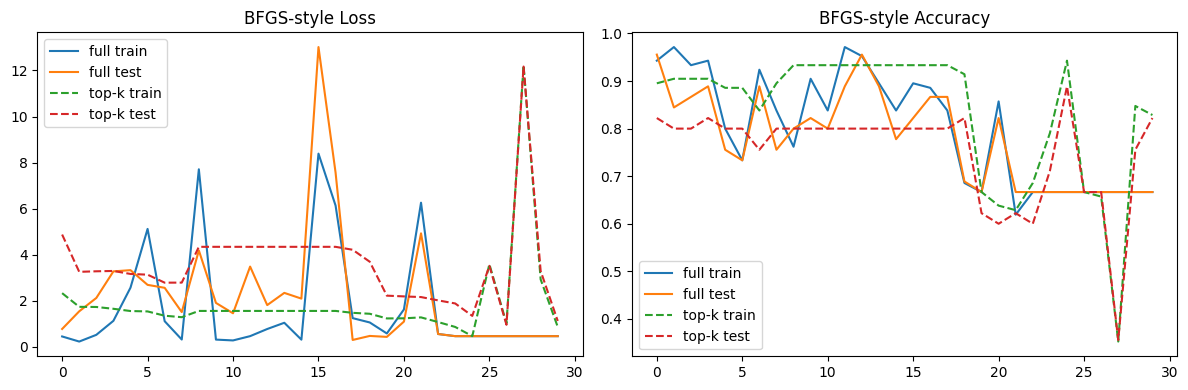

In [52]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bfgs_full_history["train_loss"], label="full train")
plt.plot(bfgs_full_history["test_loss"], label="full test")
plt.plot(bfgs_topk_history["train_loss"], label="top-k train", linestyle="--")
plt.plot(bfgs_topk_history["test_loss"], label="top-k test", linestyle="--")
plt.title("BFGS-style Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bfgs_full_history["train_accuracy"], label="full train")
plt.plot(bfgs_full_history["test_accuracy"], label="full test")
plt.plot(bfgs_topk_history["train_accuracy"], label="top-k train", linestyle="--")
plt.plot(bfgs_topk_history["test_accuracy"], label="top-k test", linestyle="--")
plt.title("BFGS-style Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Comparison

In [53]:
histories = {}
for name in ("history", "adam_history", "bfgs_full_history", "bfgs_topk_history"):
    if name in globals():
        histories[name] = globals()[name]

labels = {
    "history": "annealer",
    "adam_history": "adam",
    "bfgs_full_history": "bfgs_full",
    "bfgs_topk_history": "bfgs_topk",
}


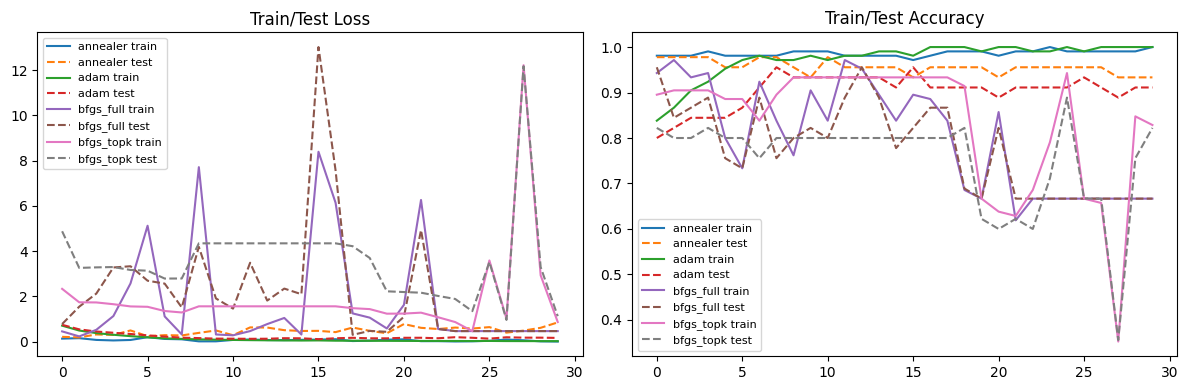

In [54]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for var_name, hist in histories.items():
    lab = labels.get(var_name, var_name)
    if "train_loss" in hist:
        plt.plot(hist["train_loss"], label=f"{lab} train")
    if "test_loss" in hist:
        plt.plot(hist["test_loss"], label=f"{lab} test", linestyle="--")
plt.title("Train/Test Loss")
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for var_name, hist in histories.items():
    lab = labels.get(var_name, var_name)
    if "train_accuracy" in hist:
        plt.plot(hist["train_accuracy"], label=f"{lab} train")
    if "test_accuracy" in hist:
        plt.plot(hist["test_accuracy"], label=f"{lab} test", linestyle="--")
plt.title("Train/Test Accuracy")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()